In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
N_USERS = 700
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

https://pubmed.ncbi.nlm.nih.gov/2043597/

tentukan ID, umur, gender, tinggi, dan berat awal.

In [26]:
user_ids = np.arange(1, N_USERS + 1)
ages = np.random.randint(17, 50, size=N_USERS)
genders = np.random.choice(['Male', 'Female'], size=N_USERS)
heights = np.random.randint(150, 200, size=N_USERS)
initial_weights = np.random.randint(40, 130, size=N_USERS)

df = pd.DataFrame({
    'User_ID': user_ids,
    'Age': ages,
    'Gender': genders,
    'Height_cm': heights,
    'Initial_Weight_kg': initial_weights
})

df.head()

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg
0,1,22,Female,187,113
1,2,30,Female,174,101
2,3,45,Male,186,80
3,4,47,Female,198,79
4,5,23,Female,193,105


menghitung dan mengklasifikasikan BMI : https://en.wikipedia.org/wiki/Body_mass_index

In [27]:
def calculate_bmi(weight_kg, height_cm):
    """
    Calculates the Body Mass Index (BMI) value based on physical attributes.

    The BMI is a simple index of weight-for-height that is commonly used to 
    classify underweight, overweight, and obesity in adults.

    Formula:
        BMI = weight (kg) / [height (m)]^2

    ---------------------------------------------------------------------------
    Args:
        weight_kg (float): The individual's body mass in kilograms.
        height_cm (float): The individual's height in centimeters.

    Returns:
        float: The calculated BMI value rounded to two decimal places.
    """
    # Convert height from centimeters to meters for the formula
    height_m = height_cm / 100
    
    # Apply standard BMI formula: weight / height^2
    return round(weight_kg / (height_m ** 2), 2)

In [28]:
df['Initial_BMI'] = calculate_bmi(
    df['Initial_Weight_kg'],
    df['Height_cm']
)

In [29]:
def classify_bmi(bmi):
    """
    Classifies a BMI score into standard weight status categories.

    This classification follows standard health guidelines (e.g., WHO standards) 
    to categorize an individual's weight status based on their calculated BMI.

    ---------------------------------------------------------------------------
    Args:
        bmi (float): The calculated Body Mass Index score.

    Returns:
        str: The corresponding weight category label ('Underweight', 'Normal', 
             'Overweight', or 'Obese').

    Classification Logic:
    - Underweight : BMI < 18.5
    - Normal      : 18.5 <= BMI < 25.0
    - Overweight  : 25.0 <= BMI < 30.0
    - Obese       : BMI > 30.0
    """
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    elif bmi > 30.0:
        return 'Obese'

# --- APPLY TO DATASET ---
# Map the classification function to the entire 'Initial_BMI' column
# Assuming 'Initial_BMI' already exists in the DataFrame 'df'
df['BMI_Category'] = df['Initial_BMI'].apply(classify_bmi)

# Verify Results
# Print the distribution to see class balance
print("Distribusi Kategori BMI User:")
print(df['BMI_Category'].value_counts())

# Preview the first 10 rows to confirm correct mapping
display(df[['User_ID', 'Initial_BMI', 'BMI_Category']].head(10))

Distribusi Kategori BMI User:
BMI_Category
Obese          310
Normal         138
Underweight    136
Overweight     114
Name: count, dtype: int64


,User_ID,Initial_BMI,BMI_Category
0,1,32.31,Obese
1,2,33.36,Obese
2,3,23.12,Normal
3,4,20.15,Normal
4,5,28.19,Overweight
5,6,31.63,Obese
6,7,21.00,Normal
7,8,28.31,Overweight
8,9,20.70,Normal
9,10,39.95,Obese


calcuate bodyfat from BMI : https://en.wikipedia.org/wiki/Body_fat_percentage <br/><br/>
bodyfat category: <br/> https://www.bodybuildingmealplan.com/iifym-calculator/
![WhatsApp Image 2026-01-21 at 3.51.07 PM.jpeg](<attachment:WhatsApp Image 2026-01-21 at 3.51.07 PM.jpeg>)
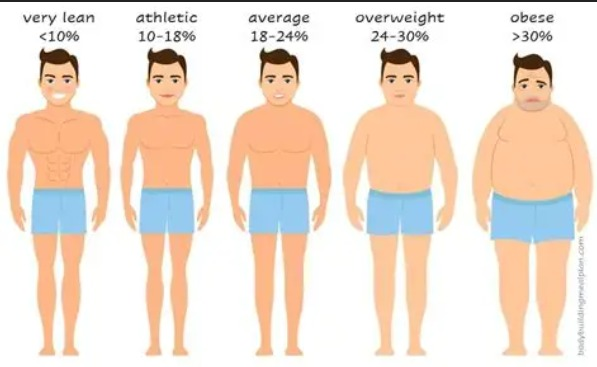

In [30]:
def calculate_fat_and_category(row):
    """
    Estimates Body Fat Percentage and determines its Category based on 
    anthropometric data.

    This function utilizes the Deurenberg formula as a baseline, introduces 
    stochastic noise for realistic variability, and classifies the result 
    into a standardized 5-point scale.

    ---------------------------------------------------------------------------
    Args:
        row (pd.Series): A DataFrame row containing:
            - 'Initial_BMI' (float): Body Mass Index.
            - 'Age' (int): User's age.
            - 'Gender' (str): 'Male' or 'Female'.

    Returns:
        tuple: (Category [int], Body_Fat_Percentage [float])
               - Category: 1 (Very Low) to 5 (Very High).
               - Percentage: Estimated body fat % rounded to 1 decimal.

    ---------------------------------------------------------------------------
    Calculation Logic:
    1.  Base Estimation: Uses the Deurenberg formula:
        (1.20 * BMI) + (0.23 * Age) - (10.8 * Sex) - 5.4 
        (Note: Coefficients may vary slightly based on specific implementation).
    
    2.  Noise Injection: Adds random uniform noise (-3% to +3%) to prevent 
        perfect multicollinearity with BMI, simulating real-world variances 
        (e.g., muscle mass differences).
    
    3.  Biological Safety Guard: Clamps the result to physiological limits 
        (Min: 3% for Men, 10% for Women; Max: 60%) to avoid impossible values.
    
    4.  Categorization: Maps the percentage to specific ranges based on the 
        provided visual guidelines/references.
    """
    bmi = row['Initial_BMI']
    age = row['Age']
    gender = row['Gender']
    
    # --- 1. COMPUTE BASE BODY FAT (Deurenberg Formula) ---
    sex_val = 1 if gender == 'Male' else 0
    # Formula: (1.39 * BMI) + (0.16 * Age) - (10.34 * Gender) - 9
    estimated_fat = (1.39 * bmi) + (0.16 * age) - (10.34 * sex_val) - 9
        
    # --- 2. ADD NOISE (Variability) ---
    # Objective: Decouple Body Fat from BMI slightly to simulate individual differences.
    # Adds a random value between -3.0% and +3.0%
    noise = np.random.uniform(-3.0, 3.0)
    final_fat = estimated_fat + noise
    
    # --- 3. SAFETY GUARD (Biological Constraints) ---
    # Minimum physiological essential fat: Men ~3%, Women ~10%
    min_limit = 3.0 if gender == 'Male' else 10.0
    max_limit = 60.0 
    
    # Clamp values within the safe range
    if final_fat < min_limit: 
        final_fat = min_limit
    elif final_fat > max_limit:
        final_fat = max_limit
        
    final_fat = round(final_fat, 1)
    
    # --- 4. DETERMINE CATEGORY ---
    # Scale Mapping: 
    # 1 (<10%), 2 (10-18%), 3 (18-24%), 4 (24-30%), 5 (>=30%)
    
    category = 0
    if final_fat < 10:
        category = 1
    elif 10 <= final_fat < 18:
        category = 2
    elif 18 <= final_fat < 24:
        category = 3
    elif 24 <= final_fat < 30:
        category = 4
    else: # >= 30
        category = 5
        
    return category, final_fat

# --- EXECUTION ---
# Apply the function to the DataFrame
# 'result_type="expand"' splits the returned tuple into two separate columns
df[['Body_Fat_Category', 'Body_Fat_Percentage']] = df.apply(
    calculate_fat_and_category, axis=1, result_type='expand'
)

# Verify Results
print("Hasil Perhitungan Lemak & Kategori:")
display(df.head())

Hasil Perhitungan Lemak & Kategori:


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage
0,1,22,Female,187,113,32.31,Obese,5.0,37.0
1,2,30,Female,174,101,33.36,Obese,5.0,40.4
2,3,45,Male,186,80,23.12,Normal,3.0,20.4
3,4,47,Female,198,79,20.15,Normal,4.0,28.7
4,5,23,Female,193,105,28.19,Overweight,5.0,32.1


memilih 3 category dalam pembentukan badan menurut : https://pmc.ncbi.nlm.nih.gov/articles/PMC3302369/

In [31]:
goals_options = ['Weight Loss', 'Muscle Gain', 'Maintain']
df['Goal'] = np.random.choice(goals_options, size=len(df))

function untuk menentukan batas wajar dari fat range dan akan digunakan untuk membantu menentukan goal

https://www.renuehealth.com/body-composition-analysis/

In [32]:
def get_healthy_fat_range(gender, age):    
    """
    Retrieves the medically recommended healthy body fat percentage range.

    This function maps a user's gender and age to specific body fat standards
    derived from health guidelines (referenced in project documentation).
    
    The classification accounts for physiological differences:
    1. Gender: Females naturally require higher essential fat stores than males.
    2. Age: Healthy fat ranges gradually increase with age due to metabolic changes.

    ---------------------------------------------------------------------------
    Args:
        gender (str): The user's biological sex ('Male' or 'Female').
        age (int): The user's age in years.

    Returns:
        tuple: A tuple containing (lower_bound, upper_bound) percentages.
               Example: (15.0, 23.0)

    ---------------------------------------------------------------------------
    Age Group Segmentation:
    - Young Adult (< 30 years)
    - Adult (30 - 39 years)
    - Middle Aged (40 - 49 years)
    - Senior (>= 50 years)
    """

    # --- MALE LOGIC ---
    if gender == 'Male':
        if age < 30:        # Segment: Young Adult (17 - 29 years)
            return 15.0, 23.0
        elif age < 40:      # Segment: Adult (30 - 39 years)
            return 16.0, 25.0
        elif age < 50:      # Segment: Middle Aged (40 - 49 years)
            return 18.0, 27.0
        else:               # Segment: Senior (50+ years)
            return 19.0, 27.0

    # --- FEMALE LOGIC ---
    else:
        if age < 30:        # Segment: Young Adult (17 - 29 years)
            return 24.0, 32.0
        elif age < 40:      # Segment: Adult (30 - 39 years)
            return 26.0, 34.0
        elif age < 50:      # Segment: Middle Aged (40 - 49 years)
            return 26.0, 35.0
        else:               # Segment: Senior (50+ years)
            return 29.0, 38.0

menentukan goal dari informasi BMI dan BodyFat <br/>
https://pmc.ncbi.nlm.nih.gov/articles/PMC2877506/

In [33]:
def set_goal(row):
    """
    Determines a medically logical and safe fitness goal based on body composition.

    This function acts as a corrective layer. It overrides the user's initial 
    choice if that choice contradicts their physiological status (e.g., preventing 
    an underweight person from choosing 'Weight Loss').

    ---------------------------------------------------------------------------
    Args:
        row (pd.Series): A DataFrame row containing:
            - 'Initial_BMI' (float)
            - 'Body_Fat_Percentage' (float)
            - 'Gender' (str)
            - 'Age' (int)
            - 'Goal' (str): The initial/random goal assignment.

    Returns:
        str: The corrected goal ('Weight Loss', 'Muscle Gain', or 'Maintain').

    ---------------------------------------------------------------------------
    Priority Logic (Safety Protocols):
    1.  Clinical Underweight (BMI < 18.5):
        MANDATORY 'Muscle Gain'. Prioritize increasing mass to reach a healthy range.
    
    2.  True Obesity (BMI > 25 & High Body Fat):
        MANDATORY 'Weight Loss'. Prioritize cardiovascular health and joint safety.
    
    3.  High Muscularity / 'False' Obesity (High BMI but Low/Normal Fat):
        Typical of athletes/gym-goers. High BMI is due to muscle weight.
        Action: Prevent 'Weight Loss', switch to 'Maintain' or 'Muscle Gain'.
    
    4.  Sarcopenic Obesity / 'Skinny Fat' (Normal BMI but High Fat):
        Low muscle mass with high body fat. 
        Action: Suggest 'Muscle Gain' to facilitate Body Recomposition.
    
    5.  Ideal Condition (Normal BMI & Normal Fat):
        User has freedom of choice, but 'Weight Loss' is discouraged to prevent 
        becoming underweight.
    """

    # --- RETRIEVE DATA ---
    bmi = row['Initial_BMI']
    body_fat = row['Body_Fat_Percentage']
    gender = row['Gender']
    age = row['Age']
    current_goal = row['Goal'] # Initial random assignment
    
    # --- GET HEALTHY FAT THRESHOLDS (Dynamic based on Age/Gender) ---
    min_fat, max_fat = get_healthy_fat_range(gender, age)
    
    # ====================================================================
    # SAFETY PRIORITY LOGIC
    # ====================================================================
    
    # 1. CHECK UNDERWEIGHT (Critical Mass Deficiency) -> BMI < 18.5
    # Regardless of body fat, this individual needs body mass.
    # Dieting is strictly prohibited.
    if bmi < 18.5:
        return 'Muscle Gain'
        
    # 2. CHECK TRUE OBESITY (High BMI & High Fat)
    # BMI indicates Overweight (>25) AND Body Fat exceeds the healthy limit.
    elif bmi >= 25.0 and body_fat > max_fat:
        return 'Weight Loss'
        
    # 3. CHECK "FALSE" OBESITY (Athletic/Muscular Build)
    # BMI is High (heavy muscle), BUT Body Fat is Healthy/Low.
    elif bmi >= 25.0 and body_fat <= max_fat:
        # This person is muscular. If they chose 'Weight Loss', correct it.
        # Losing weight might mean losing muscle, which is undesirable here.
        if current_goal == 'Weight Loss':
            return 'Maintain' # Or Muscle Gain
        else:
            return current_goal
        
    # 4. CHECK "SKINNY FAT" (Normal BMI, High Fat)
    # Appears thin in clothes, but lacks muscle definition/has visceral fat.
    elif 18.5 <= bmi < 25.0 and body_fat > max_fat:
        # Best strategy is "Body Recomposition" (Build muscle to burn fat).
        # We enforce 'Muscle Gain' to trigger resistance training recommendations.
        return 'Muscle Gain' 
        
    # 5. CHECK TOO SHREDDED (Fat below essential levels)
    elif body_fat < min_fat:
        return 'Muscle Gain' # Bulking required
        
    # ====================================================================
    # IDEAL CONDITION (Normal BMI & Healthy Fat)
    # ====================================================================
    else:
        # User is healthy. We prioritize aesthetics and maintenance.
        # We avoid extreme 'Weight Loss' to prevent them from becoming underweight.
        if current_goal == 'Weight Loss':
            # Instead of shrinking (risk of becoming frail), suggest toning.
            return 'Muscle Gain'
        else:
            # Free choice (Maintain or Muscle Gain)
            return current_goal

# Apply logic to the DataFrame
df['Goal'] = df.apply(set_goal, axis=1)

menentukan workout frequency secara acak dari rentang 2-6 hari <br/>
kenapa memilih 2-6 hari : https://pubmed.ncbi.nlm.nih.gov/19204579/

In [34]:
# ==============================================================================
# SYNTHETIC DATA GENERATION: WORKOUT HABITS
# ==============================================================================
# Objective: Populate the dataset with realistic activity patterns.
#
# Instead of using uniform randomness (where every option is equally likely), 
# we use Weighted Probability Distributions to mimic real-world human behavior.
# Most people fall into the "Average" category, with fewer people at the extremes.

# ------------------------------------------------------------------------------
# A. WORKOUT FREQUENCY (Days per Week)
# ------------------------------------------------------------------------------
# Logic:
# - Beginners typically start with 2-3 days.
# - Intermediate/Advanced users train 4-5 days.
# 
# Distribution Strategy (Bell Curve Approximation):
# - 2 Days: 20% (Low commitment / Busy schedule)
# - 3 Days: 30% (Standard maintenance / General fitness)
# - 4 Days: 30% (Dedicated fitness routine)
# - 5 Days: 20% (High dedication / Split training)

freq_probs = [0.2, 0.3, 0.3, 0.2]
df['Workout_Frequency'] = np.random.choice([2, 3, 4, 5], size=len(df), p=freq_probs)

# ------------------------------------------------------------------------------
# B. SESSION DURATION (Minutes per Session)
# ------------------------------------------------------------------------------
# Logic:
# - Based on WHO Guidelines: Adults should do at least 150–300 minutes of 
#   moderate-intensity aerobic physical activity per week.
#
# Distribution Strategy:
# - 30 Mins: 20% (HIIT / Quick cardio / Time-constrained)
# - 45 Mins: 30% (Standard gym class length)
# - 60 Mins: 30% (Standard weightlifting session)
# - 90 Mins: 20% (Endurance training / High volume sessions)

dur_probs = [0.2, 0.3, 0.3, 0.2]
df['Average_Duration_Minutes'] = np.random.choice([30, 45, 60, 90], size=len(df), p=dur_probs)

# Verify Data Generation
display(df.head())

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes
0,1,22,Female,187,113,32.31,Obese,5.0,37.0,Weight Loss,4,45
1,2,30,Female,174,101,33.36,Obese,5.0,40.4,Weight Loss,5,45
2,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60
3,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90
4,5,23,Female,193,105,28.19,Overweight,5.0,32.1,Weight Loss,4,90


menentukan 3 level experience berdasarkan frequency latihan
https://pubmed.ncbi.nlm.nih.gov/19204579/

In [35]:
def determine_experience_level(row):
    """
    Infers the user's fitness Experience Level based on their Workout Frequency.

    This function applies **Conditional Probability Logic** to generate realistic 
    user profiles. Instead of using rigid deterministic rules (e.g., "5 days always 
    equals Advanced"), we use weighted probabilities to account for real-world nuances.

    ---------------------------------------------------------------------------
    Args:
        row (pd.Series): A DataFrame row containing the 'Workout_Frequency' column.

    Returns:
        str: The inferred level ('Beginner', 'Intermediate', or 'Advanced').

    ---------------------------------------------------------------------------
    Probability Logic:
    1.  Low Frequency (< 3 days):
        - High probability (70%) of being a Beginner.
        - Small chance (15%) of being an Advanced user in a "maintenance phase" 
          or having a busy schedule.
      
    2.  Moderate Frequency (3-4 days):
        - The "Sweet Spot" for consistent training.
        - Highest probability (70%) of being an Intermediate user who has built a habit.
      
    3.  High Frequency (5+ days):
        - Requires significant dedication and recovery capacity.
        - High probability (70%) of being an Advanced athlete.
        - Low probability (15%) for Beginners due to high risk of burnout/overtraining.
    """
    
    freq = row['Workout_Frequency']

    # --- CONDITIONAL PROBABILITY LOGIC ---
    # Objective: Create a "Smart" distribution that mimics real-world demographics.
    
    # CASE 0: INACTIVE
    if freq == 0:
        return 'Beginner'

    # CASE 1: LOW FREQUENCY (< 3 Days)
    # Hypothesis: Likely a Beginner starting out, or someone with limited time.
    if freq < 3:
        # Heavily weighted towards Beginner
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.70, 0.15, 0.15])
        
    # CASE 2: MODERATE / ROUTINE (3-4 Days)
    # Hypothesis: Consistent habit, typical of Intermediate users.
    elif freq == 3 or freq == 4:
        # Heavily weighted towards Intermediate
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.15, 0.70, 0.15])
        
    # CASE 3: HIGH FREQUENCY / HARDCORE (5+ Days)
    # Hypothesis: High dedication, typical of Advanced athletes.
    else:
        # Heavily weighted towards Advanced
        # Probabilities: Beginner (15%), Intermediate (15%), Advanced (70%)
        return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.15, 0.15, 0.70])

# --- EXECUTION ---
# Apply the logic row-by-row to populate the 'level' column
# Assuming 'Workout_Frequency' column exists from the previous step
df['level'] = df.apply(determine_experience_level, axis=1)

# display(df.head(10))

membuat external exercises (olahraga umum)

In [36]:
def external_exercises(row):
    """
    Simulates external sports hobbies for a user using a Two-Stage Probabilistic approach.

    This function generates synthetic data for outdoor activities based on gender 
    and general popularity, ensuring the dataset reflects real-world behavioral patterns 
    rather than uniform randomness.

    ---------------------------------------------------------------------------
    Args:
        row (pd.Series): A DataFrame row containing the user's 'Gender'.

    Returns:
        pd.Series: A One-Hot Encoded series (binary 0/1) for columns:
                   ['Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim'].

    ---------------------------------------------------------------------------
    Logic Stages:
    
    1.  Quantity Determination (How many hobbies?):
        - Uses a probability distribution where most users have 1-2 hobbies.
        - Accounts for the scarcity of "super-active" users (3+ hobbies).
    
    2.  Type Selection (Which hobbies?):
        - Uses Weighted Sampling based on popularity (e.g., Badminton > Volleyball).
        - Applies Gender Bias: Adjusts the probability weight of 'Football' 
          significantly higher for Males compared to Females.
    """

    gender = row['Gender']
    
    # --- BASE POPULARITY WEIGHTS ---
    # Define the likelihood of a sport being chosen based on general popularity.
    # Higher value = Higher probability.
    sports_options = ['Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim']
    
    weights = {
        'Badminton': 0.8,   # Highly popular
        'Basketball': 0.3,  # Moderate
        'Volleyball': 0.25, # Niche
        'Swim': 0.4         # Moderate
    }
    
    # --- DYNAMIC WEIGHT ADJUSTMENT (Gender Bias) ---
    # Adjust specific sports weights based on biological sex demographics.
    if gender == 'Male':
        weights['Football'] = 0.7  # High preference for males
    else:
        weights['Football'] = 0.1  # Lower preference for females
        
    # --- STAGE 1: DETERMINE QUANTITY (Sparsity Control) ---
    # Define the probability mass function for the number of hobbies per person.
    # 0 hobbies: 15%
    # 1 hobby  : 40% (Mode/Most Common)
    # 2 hobbies: 30%
    # 3 hobbies: 10%
    # 4 hobbies: 4%
    # 5 hobbies: 1% (Rare outlier)
    
    num_hobbies_probs = [0.15, 0.40, 0.30, 0.10, 0.04, 0.01]
    
    # Randomly select how many hobbies this specific user has
    num_picked = np.random.choice([0, 1, 2, 3, 4, 5], p=num_hobbies_probs)
    
    # --- STAGE 2: SELECT SPECIFIC TYPES ---
    selected_sports = []
    
    if num_picked > 0:
        # Prepare lists for weighted random choice
        sport_keys = list(weights.keys())
        sport_probs = list(weights.values())
        
        # Normalize weights to ensure they sum to 1.0 (Required by NumPy)
        total_weight = sum(sport_probs)
        normalized_probs = [w / total_weight for w in sport_probs]
        
        # Perform Weighted Sampling without replacement
        # (A user cannot pick 'Badminton' twice)
        selected_sports = np.random.choice(
            sport_keys, 
            size=num_picked, 
            replace=False, 
            p=normalized_probs
        )

    # --- FORMAT OUTPUT (One-Hot Encoding) ---
    # Convert the selected list into a binary Series
    return pd.Series([
        1 if 'Badminton' in selected_sports else 0,
        1 if 'Football' in selected_sports else 0,
        1 if 'Basketball' in selected_sports else 0,
        1 if 'Volleyball' in selected_sports else 0,
        1 if 'Swim' in selected_sports else 0
    ], index=['Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim'])

# --- EXECUTION ---
# Apply logic row-by-row.
# Assuming 'df' already contains the 'Gender' column.
df_games_binary = df.apply(external_exercises, axis=1)

# Concatenate the new binary columns to the main DataFrame
df = pd.concat([df, df_games_binary], axis=1)

# Preview results
df.head(15)

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Volleyball,Swim
0,1,22,Female,187,113,32.31,Obese,5.0,37.0,Weight Loss,4,45,Intermediate,0,0,0,1,0
1,2,30,Female,174,101,33.36,Obese,5.0,40.4,Weight Loss,5,45,Advanced,1,0,0,0,1
2,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1
3,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0
4,5,23,Female,193,105,28.19,Overweight,5.0,32.1,Weight Loss,4,90,Advanced,0,0,1,0,0
5,6,46,Female,162,83,31.63,Obese,5.0,39.5,Weight Loss,2,45,Beginner,1,0,0,0,0
6,7,20,Male,189,75,21.00,Normal,2.0,15.9,Maintain,3,60,Beginner,0,1,1,0,0
7,8,49,Male,187,99,28.31,Overweight,4.0,28.8,Weight Loss,2,45,Beginner,1,1,0,1,0
8,9,30,Male,163,55,20.70,Normal,2.0,14.1,Muscle Gain,5,45,Advanced,1,1,0,0,0
9,10,48,Female,159,101,39.95,Obese,5.0,55.5,Weight Loss,4,30,Intermediate,0,0,0,1,1


function untuk menghitung current calories <br/>
https://www.sfidn.com/article/post/cara-menghitung-bmr-dengan-rumus-dan-kalkulator-bmr

In [37]:
def get_current_calories(weight, height, age, gender, freq, goal_type):
    """
    Calculates the dynamic daily caloric intake target based on current physiological status.

    This function implements the **Mifflin-St Jeor equation**, widely considered the 
    'Gold Standard' for estimating Basal Metabolic Rate (BMR) in clinical and fitness settings.

    ---------------------------------------------------------------------------
    Args:
        weight (float): Current body weight in kilograms (kg).
        height (float): Height in centimeters (cm).
        age (int): Age in years.
        gender (str): Biological sex ('Male' or 'Female').
        freq (int): Weekly workout frequency (days/week).
        goal_type (str): The fitness objective ('Weight Loss', 'Muscle Gain', 'Maintain').

    Returns:
        int: The recommended daily calorie target (kcal), rounded to the nearest integer.

    ---------------------------------------------------------------------------
    Calculation Logic:
    
    1.  BMR (Basal Metabolic Rate): 
        Energy required for basic life functions (breathing, circulation) at rest.
        Formula: (10 * Weight) + (6.25 * Height) - (5 * Age) + S
                 Where S = +5 for Males, -161 for Females.
    
    2.  TDEE (Total Daily Energy Expenditure):
        BMR adjusted by an Activity Factor based on workout frequency.
        - Sedentary (0-1 days)      : BMR * 1.2
        - Lightly Active (2-3 days) : BMR * 1.375
        - Moderately Active (4-5 days): BMR * 1.55
        - Very Active (6+ days)     : BMR * 1.725
    
    3.  Goal Adjustment:
        - Weight Loss: TDEE - 500 kcal (Creates ~0.5kg/week deficit).
        - Muscle Gain: TDEE + 300 kcal (Surplus to fuel hypertrophy).
        - Maintain   : TDEE (Energy Balance).
    
    4.  Safety Floor (Metabolic Protection):
        Prevents recommending dangerously low calorie intakes that could crash metabolism.
        - Male Limit  : Min 1500 kcal.
        - Female Limit: Min 1200 kcal.
    """

    # --- 1. CALCULATE BASAL METABOLIC RATE (BMR) ---
    # Using the Mifflin-St Jeor equation
    if gender == 'Male':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161
    
    # --- 2. DETERMINE ACTIVITY MULTIPLIER (TDEE) ---
    # Adjusts BMR based on reported weekly activity levels
    if freq <= 1: multiplier = 1.2
    elif freq <= 3: multiplier = 1.375
    elif freq <= 5: multiplier = 1.55
    else: multiplier = 1.725
    
    tdee = bmr * multiplier
    
    # --- 3. APPLY GOAL ADJUSTMENT ---
    # Modifies TDEE to create a Caloric Deficit or Surplus
    if goal_type == 'Weight Loss':
        target = tdee - 500
    elif goal_type == 'Muscle Gain':
        target = tdee + 300
    else:
        target = tdee
    
    # --- 4. SAFETY FLOOR CHECK ---
    # Ensure calories do not drop below medically recommended minimums
    min_cal = 1500 if gender == 'Male' else 1200
    
    return max(int(target), min_cal)

menghitung water intake : <br/>
https://www.apnacalculator.com/tools/health/water-intake.php?utm_source=chatgpt.com

In [38]:
def get_water_needs(weight, duration):
    """
    Estimates the total daily hydration requirement (in milliliters).

    This calculation synthesizes two critical components:
    1.  Baseline Hydration:
        Utilizes the general health standard of ~35ml per kilogram of body weight 
        to support metabolic functions, thermoregulation, and organ health.
        
    2.  Exercise Compensation (Sweat Loss):
        Estimates fluid loss during physical activity. Adopts a moderate guideline 
        of ~10ml per minute of exercise (equivalent to 600ml/hour), aligning with 
        ACSM recommendations for moderate-intensity workouts.

    ---------------------------------------------------------------------------
    Args:
        weight (float): Current body weight in kilograms (kg).
        duration (int): Average duration of workout sessions in minutes.

    Returns:
        int: The recommended daily water intake target (ml).
    """
  
    # --- 1. CALCULATE BASELINE NEEDS ---
    # Standard: ~35ml per kg of body weight
    base_water = weight * 35 
  
    # --- 2. CALCULATE ACTIVITY NEEDS ---
    # Compensation for sweat loss: ~10-12ml per minute of exercise
    # (e.g., 60 mins workout = +600ml to +700ml)
    activity_water = duration * 10
  
    total_ml = base_water + activity_water
    
    return int(total_ml)

In [39]:
def enrich_nutrition_data(goal, calories):
    """
    Calculates comprehensive nutritional breakdowns (Macros & Frequency).

    This function determines the optimal distribution of daily calories into 
    protein, carbohydrates, and fats based on specific fitness goals, while 
    also recommending a meal frequency that aligns with total caloric volume.

    ---------------------------------------------------------------------------
    Args:
        goal (str): The user's fitness objective ('Muscle Gain', 'Weight Loss', 
                    or 'Maintain').
        calories (float/int): Total daily caloric intake target.

    Returns:
        pd.Series: A series containing [Protein_g, Carbs_g, Fat_g, Frequency].

    ---------------------------------------------------------------------------
    Macro-Nutrient Split Logic:
    1.  Muscle Gain (Hypertrophy Focus): 
        - High Carbohydrate (50%) to fuel intense training sessions.
        - Moderate Protein (30%) for muscle tissue repair.
        - Moderate Fat (20%) for hormonal health.
        
    2.  Weight Loss (Satiety & Muscle Retention Focus):
        - High Protein (40%) to prevent muscle catabolism during a deficit 
          and increase satiety (TEF).
        - Balanced Carbs (30%) and Fats (30%) to maintain energy and metabolic health.
        
    3.  Maintain (Balanced Equilibrium):
        - Standard Balanced Diet (40% Carbs, 30% Protein, 30% Fat).
        
    Meal Frequency Logic:
    - Designed to manage gastric volume and prevent bloating.
    - Low Calorie (<1500): 3 meals (Maintains satiety between meals).
    - Moderate Calorie (1500-2200): 4 meals (3 meals + 1 snack).
    - High Calorie (>2200): 5 meals (3 meals + 2 snacks to ensure calorie completion).
    """

    # --- 1. MACRONUTRIENT RATIO LOGIC (Goal-Based) ---
    # Ratios are based on percentage of total calories.
    if goal == 'Muscle Gain':
        # High Carb Strategy (50% C, 30% P, 20% F)
        p_ratio, c_ratio, f_ratio = 0.30, 0.50, 0.20
    elif goal == 'Weight Loss':
        # High Protein Strategy (40% P, 30% C, 30% F)
        p_ratio, c_ratio, f_ratio = 0.40, 0.30, 0.30
    else: # Maintain / Balanced
        p_ratio, c_ratio, f_ratio = 0.30, 0.40, 0.30
        
    # --- CONVERSION TO GRAMS ---
    # Protein: 4 kcal/gram | Carbs: 4 kcal/gram | Fat: 9 kcal/gram
    prot_g = int((calories * p_ratio) / 4)
    carbs_g = int((calories * c_ratio) / 4)
    fat_g = int((calories * f_ratio) / 9)
    
    # --- 2. MEAL FREQUENCY LOGIC (Volume Management) ---
    # Higher caloric intake requires more frequent feedings to prevent excessive fullness.
    if calories < 1500:
        freq = 3  # 3 Main Meals (No snacks)
    elif calories < 2200:
        freq = 4  # 3 Main Meals + 1 Snack
    else:
        freq = 5  # 3 Main Meals + 2 Snacks
        
    return pd.Series([prot_g, carbs_g, fat_g, freq])

In [40]:
def get_additional_nutrients(calories):
    """
    Calculates essential micronutrient targets and limits based on caloric intake.

    This function applies international health standards to ensure nutritional 
    quality beyond caloric quantity, focusing on heart health, metabolic 
    regulation, and bone density.

    ---------------------------------------------------------------------------
    Args:
        calories (int/float): The user's total daily caloric intake target.

    Returns:
        tuple: A tuple containing (Sugar_Limit_g, Fiber_Target_g, 
               Cholesterol_Limit_mg, Calcium_Target_mg).

    ---------------------------------------------------------------------------
    Nutritional Standards Logic:
    1.  Fiber (Target): 
        - Based on USDA Guidelines: 14 grams of fiber per 1,000 kcal.
        - Essential for digestive health, satiety, and glycemic control.
    
    2.  Free Sugar (Limit): 
        - Based on WHO Guidelines: Capped at a maximum of 10% of total daily 
          calories to mitigate diabetes and obesity risks.
        - Conversion: 1 gram of sugar = 4 kcal.
    
    3.  Cholesterol (Limit): 
        - Aligns with general heart health standards: Below 300mg per day.
    
    4.  Calcium (Target): 
        - Follows the general Recommended Dietary Allowance (RDA) for adults: 
          1,000mg to support bone density and muscular function.
    """

    # --- 1. FIBER CALCULATION ---
    # USDA standard: 14g fiber per 1,000 calories
    fiber_g = int((calories / 1000) * 14)
    
    # --- 2. FREE SUGAR LIMIT ---
    # WHO recommendation: Maximum 10% of total caloric intake
    # Converting caloric limit to mass (grams)
    sugar_cal_limit = calories * 0.10
    sugar_g = int(sugar_cal_limit / 4)
    
    # --- 3. CHOLESTEROL LIMIT ---
    # Standard threshold for maintaining cardiovascular health
    cholesterol_mg = 300
    
    # --- 4. CALCIUM TARGET ---
    # General RDA for bone and neuromuscular maintenance
    calcium_mg = 1000
    
    return sugar_g, fiber_g, cholesterol_mg, calcium_mg

https://bodyrecomposition.com/muscle-gain/genetic-muscular-potential
https://pubmed.ncbi.nlm.nih.gov/21558571/
https://www.sciencedirect.com/science/article/pii/S0002916523277187?utm_source=chatgpt.com

In [41]:
def generate_time_series_progress(users_df, total_weeks=12):
    """
    Simulates a 12-week physiological progress trajectory (Time Series) for users.

    This function applies established scientific models to forecast how weight, 
    body fat, and nutritional requirements evolve over time. It mimics real-world 
    conditions, including metabolic adaptation and non-linear weight changes.

    ---------------------------------------------------------------------------
    Args:
        users_df (pd.DataFrame): The initial user profile baseline (Week 0).
        total_weeks (int): Duration of the simulation in weeks (Default: 12).

    Returns:
        pd.DataFrame: A long-format DataFrame containing weekly progress metrics.

    ---------------------------------------------------------------------------
    Scientific Models & Logic:
    
    1.  Hypertrophy Rate (Alan Aragon & Helms et al.):
        Muscle gain is biologically capped. The simulation applies a diminishing 
        rate where Beginners gain ~1.5% body weight/month, while Advanced users 
        gain ~0.5%, preventing unrealistic "mass gain" predictions.
    
    2.  Sustainable Weight Loss (Helms 2014 Guideline):
        Targets a healthy loss of 0.5% - 1.0% body weight per week. It includes 
        'Stochastic Noise' to simulate water retention and glycogen fluctuations, 
        ensuring the weight loss curve is non-linear (as in real life).
        
    3.  Homeostasis (Maintain):
        Simulates physiological stability with minor random fluctuations around 
        the set point.
    
    4.  Metabolic Adaptation (Dynamic Recalculation):
        Every 4 weeks (1 block), the system recalculates caloric and macro 
        requirements. As weight changes, the Total Daily Energy Expenditure (TDEE) 
        shifts, requiring diet adjustments to prevent progress plateaus.
    """

    progress_list = []

    for index, row in users_df.iterrows():
        # --- INITIAL BASELINE EXTRACTION (Week 0) ---
        user_id = row['User_ID']
        gender = row['Gender']
        height_m = row['Height_cm'] / 100
        start_weight = row['Initial_Weight_kg']
        start_fat = row['Body_Fat_Percentage']
        goal = row['Goal']
        level = row['level'] 
        
        height_cm = row['Height_cm']
        age = row['Age']                   
        freq = row['Workout_Frequency']
        duration_min = row['Average_Duration_Minutes']
        
        current_weight = start_weight
        current_fat = start_fat
        
        # Calculate initial nutritional requirements
        calories = get_current_calories(current_weight, height_cm, age, gender, freq, goal)
        water = get_water_needs(current_weight, duration_min)
        prot_g, carbs_g, fat_g, freq_meal = enrich_nutrition_data(goal, calories)
        sugar_g, fiber_g, chol_mg, calc_mg = get_additional_nutrients(calories)

        # Record Initial State (Week 0)
        progress_list.append({
            'User_ID': user_id,
            'Week': 0,
            'Weight_kg': round(current_weight, 2),
            'BMI': round(current_weight / (height_m**2), 2),
            'Body_Fat_Percentage': round(current_fat, 1),
            'Daily_Calories': calories,
            'Daily_Water_ml': water,
            'Target_Protein_g': prot_g,
            'Target_Carbs_g': carbs_g,
            'Target_Fat_g': fat_g,
            'Limit_Sugar_g': sugar_g,
            'Target_Fiber_g': fiber_g,
            'Limit_Cholesterol_mg': chol_mg,
            'Target_Calcium_mg': calc_mg,
            'Meal_Frequency': freq_meal,
        })
        
        # --- PROGRESSION LOOP (Weeks 1 to 12) ---
        for week in range(1, total_weeks + 1):
            
            weight_change = 0
            fat_change = 0
            
            # --- MODEL 1: MUSCLE GAIN (ARAGON/HELMS MODEL) ---
            # Monthly rates converted to weekly probability distributions.
            if goal == 'Muscle Gain':
                if level == 'Beginner':
                    # Target: ~1.0% - 1.5% BW per month
                    rate_pct = np.random.uniform(0.0025, 0.0038)
                elif level == 'Intermediate':
                    # Target: ~0.5% - 1.0% BW per month
                    rate_pct = np.random.uniform(0.0012, 0.0025)
                else: # Advanced
                    # Target: ~0.25% - 0.5% BW per month
                    rate_pct = np.random.uniform(0.0006, 0.0012)
                
                # Convert percentage to mass (kg) and add hydration noise
                weight_gain_kg = current_weight * rate_pct
                weight_change = weight_gain_kg + np.random.uniform(-0.1, 0.1)
                
                # Fat % typically stays stable or drops slightly during lean bulks
                fat_change = np.random.uniform(-0.3, 0.1)

            # --- MODEL 2: WEIGHT LOSS (HELMS 2014 GUIDELINES) ---
            # Healthy deficit resulting in 0.5% to 1.0% loss per week.
            elif goal == 'Weight Loss':
                loss_pct = np.random.uniform(0.005, 0.01)
                target_loss_kg = current_weight * loss_pct
                
                # Simulation of "Stochastic Noise" (Non-linear weight loss)
                # Mimics cortisol-induced water retention (stalls and whooshes).
                water_fluctuation = np.random.uniform(-0.5, 0.5)
                weight_change = -(target_loss_kg) + water_fluctuation
                
                # Fat loss usually accounts for the majority of weight loss with high protein
                fat_change = np.random.uniform(-0.8, -0.3)
            
            # --- MODEL 3: MAINTAIN (HOMEOSTASIS) ---
            else:
                # Pure metabolic/glycogen/water fluctuations
                weight_change = np.random.uniform(-0.5, 0.5)
                fat_change = np.random.uniform(-0.2, 0.2)

            # --- STATE UPDATE ---
            current_weight += weight_change
            current_fat += fat_change
            
            # BIOLOGICAL SAFETY GUARD (Essential Fat Protection)
            # Prevents fat percentage from dropping below survival limits.
            min_fat_limit = 5.0 if gender == 'Male' else 12.0
            if current_fat < min_fat_limit: 
                current_fat = min_fat_limit
            
            # --- DYNAMIC ADAPTATION (EVERY 4 WEEKS) ---
            # Recalculate BMR and TDEE based on the new weight.
            temp_cal = get_current_calories(current_weight, height_cm, age, gender, freq, goal)
            temp_water = get_water_needs(current_weight, duration_min)
            temp_prot, temp_carb, temp_fat, temp_freq = enrich_nutrition_data(goal, temp_cal)
            temp_sugar, temp_fiber, temp_chol, temp_calc = get_additional_nutrients(temp_cal)

            if week % 4 == 0:
                # Apply new nutritional thresholds to the next block
                calories = temp_cal
                water = temp_water
                prot_g, carbs_g, fat_g, freq_meal = temp_prot, temp_carb, temp_fat, temp_freq
                sugar_g, fiber_g, chol_mg, calc_mg = temp_sugar, temp_fiber, temp_chol, temp_calc

            # Record Weekly Progress Snapshot
            progress_list.append({
                'User_ID': user_id,
                'Week': week,
                'Weight_kg': round(current_weight, 2),
                'BMI': round(current_weight / (height_m**2), 2),
                'Body_Fat_Percentage': round(current_fat, 1),
                'Daily_Calories': calories,
                'Daily_Water_ml': water,
                'Target_Protein_g': prot_g,
                'Target_Carbs_g': carbs_g,
                'Target_Fat_g': fat_g,
                'Limit_Sugar_g': sugar_g,
                'Target_Fiber_g': fiber_g,
                'Limit_Cholesterol_mg': chol_mg,
                'Target_Calcium_mg': calc_mg,
                'Meal_Frequency': freq_meal
            })

    return pd.DataFrame(progress_list)

# --- EXECUTION ---
# Generates the long-format time-series dataset
df_weekly_progress = generate_time_series_progress(df, total_weeks=12)

In [42]:
display(df_weekly_progress[df_weekly_progress['User_ID'] == 3].head(16))
display(df_weekly_progress[df_weekly_progress['User_ID'] == 4].head(16))

,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency
26,3,0,80.00,23.12,20.4,2395,3400,179,239,79,59,33,300,1000,5
27,3,1,80.48,23.26,20.6,2395,3400,179,239,79,59,33,300,1000,5
28,3,2,80.44,23.25,20.6,2395,3400,179,239,79,59,33,300,1000,5
29,3,3,80.20,23.18,20.8,2395,3400,179,239,79,59,33,300,1000,5
30,3,4,80.25,23.20,20.8,2399,3408,179,239,79,59,33,300,1000,5
31,3,5,80.09,23.15,20.7,2399,3408,179,239,79,59,33,300,1000,5
32,3,6,80.41,23.24,20.6,2399,3408,179,239,79,59,33,300,1000,5
33,3,7,80.26,23.20,20.7,2399,3408,179,239,79,59,33,300,1000,5
34,3,8,80.47,23.26,20.5,2402,3416,180,240,80,60,33,300,1000,5
35,3,9,80.42,23.25,20.7,2402,3416,180,240,80,60,33,300,1000,5


,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency
39,4,0,79.00,20.15,28.7,2243,3665,168,224,74,56,31,300,1000,5
40,4,1,78.70,20.07,28.8,2243,3665,168,224,74,56,31,300,1000,5
41,4,2,78.29,19.97,28.7,2243,3665,168,224,74,56,31,300,1000,5
42,4,3,78.05,19.91,28.7,2243,3665,168,224,74,56,31,300,1000,5
43,4,4,77.55,19.78,28.6,2223,3614,166,222,74,55,31,300,1000,5
44,4,5,78.05,19.91,28.7,2223,3614,166,222,74,55,31,300,1000,5
45,4,6,77.70,19.82,28.8,2223,3614,166,222,74,55,31,300,1000,5
46,4,7,78.17,19.94,28.8,2223,3614,166,222,74,55,31,300,1000,5
47,4,8,78.52,20.03,28.9,2236,3648,167,223,74,55,31,300,1000,5
48,4,9,78.69,20.07,28.8,2236,3648,167,223,74,55,31,300,1000,5


link sama seperti diatas tadi

In [43]:
def get_bmi_category_label(bmi):
    """
    Translates a numerical BMI score into a standardized health category label.

    This function utilizes the World Health Organization (WHO) classification 
    standards to provide a qualitative assessment of an individual's weight 
    status based on their BMI.

    ---------------------------------------------------------------------------
    Args:
        bmi (float): The calculated Body Mass Index value.

    Returns:
        str: The health category label ('Underweight', 'Normal', 'Overweight', 
             or 'Obese').

    ---------------------------------------------------------------------------
    Health Classification Standards:
    1. Underweight (BMI < 18.5): Suggests mass deficiency relative to height.
    2. Normal (18.5 <= BMI < 25.0): Represents the healthy/ideal weight range.
    3. Overweight (25.0 <= BMI < 30.0): Indicates a mild excess in body mass.
    4. Obese (BMI >= 30.0): High mass excess associated with increased health risks.
    """
    
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

# --- 2. APPLY TO WEEKLY PROGRESS DATAFRAME ---
# Objective: Generate a categorical label for each weekly data point.
# This assumes 'df_weekly_progress' has been generated in the previous step.
df_weekly_progress['BMI_Category'] = df_weekly_progress['BMI'].apply(get_bmi_category_label)

# --- VERIFICATION ---
# Display results for User ID 3 (Sample Monitoring)
display(df_weekly_progress[df_weekly_progress['User_ID'] == 3].head(13))

# Display results for User ID 32 (Weight Loss - Intermediate Case)
display(df_weekly_progress[df_weekly_progress['User_ID'] == 32].head(13))

,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category
26,3,0,80.00,23.12,20.4,2395,3400,179,239,79,59,33,300,1000,5,Normal
27,3,1,80.48,23.26,20.6,2395,3400,179,239,79,59,33,300,1000,5,Normal
28,3,2,80.44,23.25,20.6,2395,3400,179,239,79,59,33,300,1000,5,Normal
29,3,3,80.20,23.18,20.8,2395,3400,179,239,79,59,33,300,1000,5,Normal
30,3,4,80.25,23.20,20.8,2399,3408,179,239,79,59,33,300,1000,5,Normal
31,3,5,80.09,23.15,20.7,2399,3408,179,239,79,59,33,300,1000,5,Normal
32,3,6,80.41,23.24,20.6,2399,3408,179,239,79,59,33,300,1000,5,Normal
33,3,7,80.26,23.20,20.7,2399,3408,179,239,79,59,33,300,1000,5,Normal
34,3,8,80.47,23.26,20.5,2402,3416,180,240,80,60,33,300,1000,5,Normal
35,3,9,80.42,23.25,20.7,2402,3416,180,240,80,60,33,300,1000,5,Normal


,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category
403,32,0,121.00,40.43,56.3,2140,4685,214,160,71,53,29,300,1000,4,Obese
404,32,1,119.84,40.04,55.5,2140,4685,214,160,71,53,29,300,1000,4,Obese
405,32,2,118.63,39.64,55.2,2140,4685,214,160,71,53,29,300,1000,4,Obese
406,32,3,117.54,39.27,54.7,2140,4685,214,160,71,53,29,300,1000,4,Obese
407,32,4,117.16,39.15,54.1,2087,4550,208,156,69,52,29,300,1000,4,Obese
408,32,5,116.74,39.01,53.6,2087,4550,208,156,69,52,29,300,1000,4,Obese
409,32,6,116.22,38.83,53.1,2087,4550,208,156,69,52,29,300,1000,4,Obese
410,32,7,115.93,38.73,52.8,2087,4550,208,156,69,52,29,300,1000,4,Obese
411,32,8,114.61,38.29,52.5,2052,4461,205,153,68,51,28,300,1000,4,Obese
412,32,9,113.11,37.79,52.1,2052,4461,205,153,68,51,28,300,1000,4,Obese


In [44]:
# ==============================================================================
# DATA INTEGRATION: JOINING PROFILE & PROGRESS DATA
# ==============================================================================
# Objective: Combine static user metadata with dynamic time-series progression.
#
# Why is this necessary?
# To train a predictive model, we need both the baseline characteristics (Age, 
# Height, Goal) and the resulting outcomes (Weekly Weight, Calorie Targets) in 
# a single unified structure (Flat Table).

# --- 1. PERFORM LEFT JOIN ---
# We use a 'left' join on 'User_ID' to ensure that every weekly record in the 
# progression table is correctly mapped to its corresponding user profile.
df_merged = pd.merge(
    df,                        # Left Table: User Profiles (Static Data)
    df_weekly_progress,        # Right Table: Weekly Progress (Dynamic Data)
    on='User_ID',              # Primary Key / Join Key
    how='left'                 # Join Type
)

# --- 2. DATA SORTING & ORGANIZING ---
# To maintain the logical flow of time-series data, we sort the records 
# primarily by User_ID and secondarily by the chronological order of Weeks.
df_merged = df_merged.sort_values(by=['User_ID', 'Week'])

# --- 3. VERIFICATION & INSPECTION ---
# Validating the merge results by inspecting specific user archetypes.

# Case Study: Sample User ID 3 (Monitoring Muscle Gain trajectory)
print("Contoh Data Merged (User ID 3):")
display(df_merged[df_merged['User_ID'] == 3].head(12))

# Case Study: Sample User ID 4 (Monitoring Weight Loss trajectory)
print("\nContoh Data Merged (User ID 4):")
display(df_merged[df_merged['User_ID'] == 4].head(12))

Contoh Data Merged (User ID 3):


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category_x,Body_Fat_Category,Body_Fat_Percentage_x,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Volleyball,Swim,Week,Weight_kg,BMI,Body_Fat_Percentage_y,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category_y
26,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,0,80.00,23.12,20.4,2395,3400,179,239,79,59,33,300,1000,5,Normal
27,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,1,80.48,23.26,20.6,2395,3400,179,239,79,59,33,300,1000,5,Normal
28,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,2,80.44,23.25,20.6,2395,3400,179,239,79,59,33,300,1000,5,Normal
29,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,3,80.20,23.18,20.8,2395,3400,179,239,79,59,33,300,1000,5,Normal
30,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,4,80.25,23.20,20.8,2399,3408,179,239,79,59,33,300,1000,5,Normal
31,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,5,80.09,23.15,20.7,2399,3408,179,239,79,59,33,300,1000,5,Normal
32,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,6,80.41,23.24,20.6,2399,3408,179,239,79,59,33,300,1000,5,Normal
33,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,7,80.26,23.20,20.7,2399,3408,179,239,79,59,33,300,1000,5,Normal
34,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,8,80.47,23.26,20.5,2402,3416,180,240,80,60,33,300,1000,5,Normal
35,3,45,Male,186,80,23.12,Normal,3.0,20.4,Maintain,2,60,Intermediate,0,1,1,0,1,9,80.42,23.25,20.7,2402,3416,180,240,80,60,33,300,1000,5,Normal



Contoh Data Merged (User ID 4):


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category_x,Body_Fat_Category,Body_Fat_Percentage_x,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Volleyball,Swim,Week,Weight_kg,BMI,Body_Fat_Percentage_y,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category_y
39,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,0,79.00,20.15,28.7,2243,3665,168,224,74,56,31,300,1000,5,Normal
40,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,1,78.70,20.07,28.8,2243,3665,168,224,74,56,31,300,1000,5,Normal
41,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,2,78.29,19.97,28.7,2243,3665,168,224,74,56,31,300,1000,5,Normal
42,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,3,78.05,19.91,28.7,2243,3665,168,224,74,56,31,300,1000,5,Normal
43,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,4,77.55,19.78,28.6,2223,3614,166,222,74,55,31,300,1000,5,Normal
44,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,5,78.05,19.91,28.7,2223,3614,166,222,74,55,31,300,1000,5,Normal
45,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,6,77.70,19.82,28.8,2223,3614,166,222,74,55,31,300,1000,5,Normal
46,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,7,78.17,19.94,28.8,2223,3614,166,222,74,55,31,300,1000,5,Normal
47,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,8,78.52,20.03,28.9,2236,3648,167,223,74,55,31,300,1000,5,Normal
48,4,47,Female,198,79,20.15,Normal,4.0,28.7,Maintain,3,90,Intermediate,0,0,1,1,0,9,78.69,20.07,28.8,2236,3648,167,223,74,55,31,300,1000,5,Normal


In [45]:
df.to_csv('../../data/dataset_users.csv', index=False)
df_merged.to_csv('../../data/dataset_userprogress.csv', index=False)